## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from data_tools.collections import TimeSeries
from data_tools.query import DBClient
from datetime import datetime
from scipy import stats
from scipy.signal import savgol_filter

## Data Acquisition

First, we extract the four cruise tests done without regenerative braking. The data must be fetched from InfluxDB every time this analysis is run because self.ureg inside TimeSeries cannot be serialized.

I first manually identified each cruise test. Each START_TIME and its corresponding STOP_TIME spans the acceleration time, cruising time, and braking time. 

In [2]:
START_TIMES = [datetime.fromisoformat("2026-04-02T20:02:25Z"),
                datetime.fromisoformat("2026-04-02T20:07:05Z"),
                datetime.fromisoformat("2026-04-02T20:25:57Z"),
                datetime.fromisoformat("2026-04-02T20:35:34Z"),]
    
STOP_TIMES = [datetime.fromisoformat("2026-04-02T20:03:02Z"),
                datetime.fromisoformat("2026-04-02T20:07:31Z"),
                datetime.fromisoformat("2026-04-02T20:26:38Z"),
                datetime.fromisoformat("2026-04-02T20:36:12Z"),]


Next, I queried MotorRotatingSpeed, PackCurrent, BrakePressed, and Acceleration_Z from Influx. PackCurrent is used to identify the start of the cruising period, BrakePressed identifies the end, and Acceleration_Z is IMU acceleration in the forwards direction.

In [ ]:
client = DBClient()
PACK_CURRENT_THRESHOLD = 0.10682  # pack current never reads 0; its lowest value is this constant (constant is rounded up here)

cruise_speeds: list[TimeSeries] = []
cruise_pack_currents: list[TimeSeries] = []    
cruise_brake_presseds: list[TimeSeries] = []     
cruise_imu_zs: list[TimeSeries] = []

for start, stop in zip(START_TIMES, STOP_TIMES):
    motor_rotating_speed: TimeSeries = client.query_time_series(start=start, stop=stop, field="MotorRotatingSpeed", units="km/h")
    pack_current: TimeSeries = client.query_time_series(start=start, stop=stop, field="PackCurrent", units="A")
    brake_pressed: TimeSeries = client.query_time_series(start=start, stop=stop, field="BrakePressed")
    imu_z: TimeSeries = client.query_time_series(start=start, stop=stop, field="Acceleration_Z")

    motor_rotating_speed, pack_current, brake_pressed, imu_z = TimeSeries.align( # different sampling rates for each data, so we align early to prevent issues later
        motor_rotating_speed, pack_current, brake_pressed, imu_z
    ) 

    cruise_speeds.append(motor_rotating_speed)
    cruise_pack_currents.append(pack_current)
    cruise_brake_presseds.append(brake_pressed)
    cruise_imu_zs.append(imu_z)

## Analysis

### Plots of the entire cruise, from start to stop

First, let's visualize each run in this notebook with speed vs time and acceleration vs time graphs for the entire run (from when the car speeds up from rest to when the car reaches 0 km/h again)

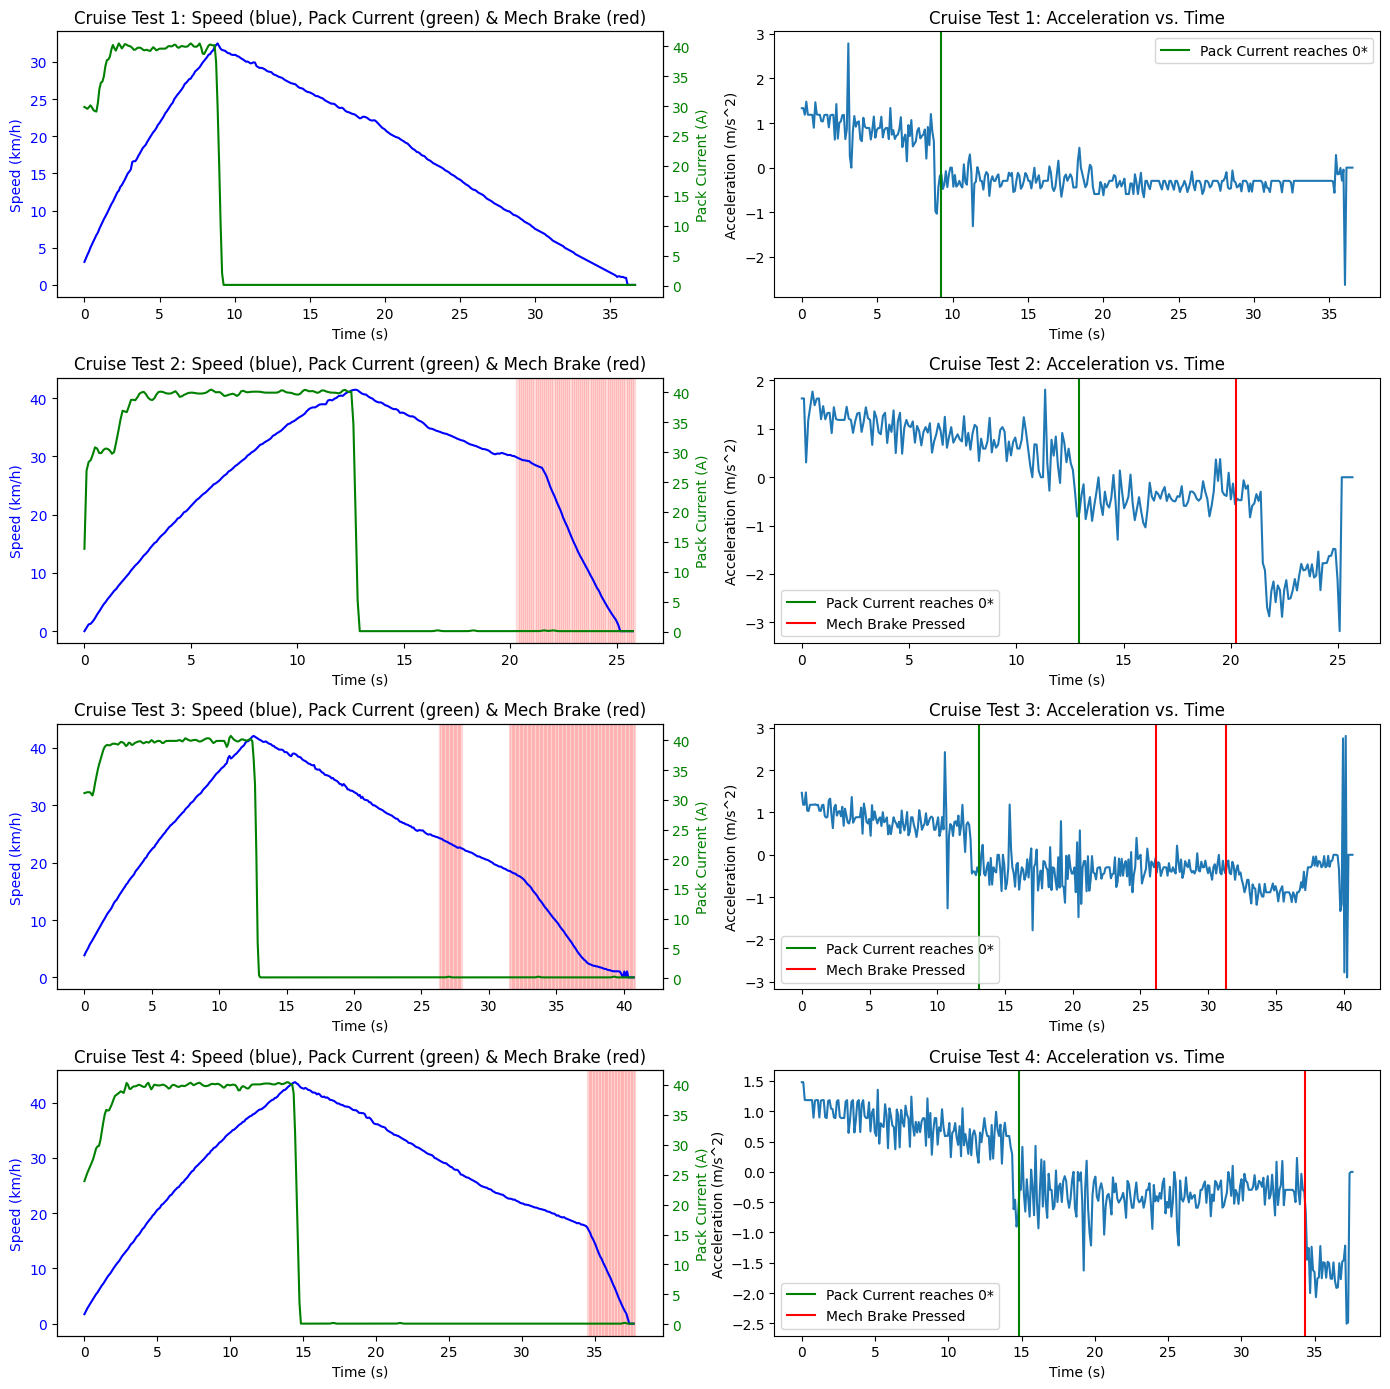

In [25]:
KMH_PER_MPS = 3.6
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    t_axis = speed.x_axis
    period = speed.period
    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS  # np.asarray(speed) turns TimeSeries into a basic np.ndarray, guaranteeing these operations work (this will be done throughout this analysis). otherwise, there is an issue with ureg.

    # Left plot: speed and pack current
    ax1 = axes[i, 0]
    ax1.plot(t_axis, speed, color="blue")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Speed (km/h)", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Cruise Test {i+1}: Speed (blue), Pack Current (green) & Mech Brake (red)")

    ax2 = ax1.twinx()
    ax2.plot(t_axis, current, color="green")
    ax2.set_ylabel("Pack Current (A)", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    for j, value in enumerate(brake):
        if value == 1:
            ax1.axvspan(t_axis[j], t_axis[j]+period, color="red", alpha=0.1)  # Highlight background when brake is pressed
    
    # Right plot: acceleration
    ax3 = axes[i, 1]
    ax3.plot(t_axis[:-1], acceleration)  # np.diff results in a 1 item shorter array

    cruise_start_time = t_axis[np.where(current <= PACK_CURRENT_THRESHOLD)[0][0]]
    ax3.axvline(cruise_start_time, c="green", label = "Pack Current reaches 0*") # star because current technically reaches PACK_CURRENT_THRESHOLD. I am assuming it is a sensor issue?

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size > 0:
        # in this if statement, I"m identifying brake "groups" (i.e. each time the brake was pressed down) and plottng each group as a separate line. 
        gap_indices = np.where(np.diff(brake_indices) > 1)[0]
        brake_start_indices = np.concatenate([[brake_indices[0]], brake_indices[gap_indices + 1]])
        for j, brake_start_index in enumerate(brake_start_indices):
            brake_time = brake_start_index * period
            label = "Mech Brake Pressed" if j == 0 else "_nolegend_"
            ax3.axvline(brake_time, c="red", label = label)

    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Acceleration (m/s^2)")
    ax3.legend()
    ax3.set_title(f"Cruise Test {i+1}: Acceleration vs. Time")

plt.tight_layout()
plt.show()


### Extracting the cruise test windows

The cruise test is the section of the run where the only forces acting on the car are rolling resistance and drag. This is the section where pack current drops to 0 and the mech brake has not been pressed yet. For each test, we"ll extract the speed as a TimeSeries during this window. I also extract the actual cruise windows as datetime. I will use these windows to get IMU acceleration later on.

In [9]:
cruise_window_speeds: list[TimeSeries] = []          
cruise_windows: list[tuple[datetime, datetime]] = [] # to extract IMU acceleration cruise window later on

for speed, current, brake in zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds):
    cruise_start_index = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0]

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size == 0:
        # for runs where brake wasn't pressed, end the cruise when speed == 0 (needed for run 1)
        zero_speed_indices = np.where(speed == 0)[0]
        cruise_end_index = zero_speed_indices[0]        
    else:    
        cruise_end_index = brake_indices[0]

    cruise_start_time = current.datetime_x_axis[cruise_start_index]
    cruise_end_time = brake.datetime_x_axis [cruise_end_index]
    cruise_windows.append((cruise_start_time, cruise_end_time))

    cruise_window_speed = speed.slice(cruise_start_time, cruise_end_time)

    cruise_window_speeds.append(cruise_window_speed)

### Attempt 1: extracting acceleration by deriving speed

The plot we want is force as a function of speed during the cruise test window. By fitting a quadratic curve to this plot, we can use the coefficient on the squared term of the equation of the curve to determine the drag area coefficient.  

We just extracted the speed we need to make this plot in the code above. Now, we need to get the y axis of the plot: force. This is the same thing as getting acceleration (F = ma, and m = 350kg from the 2025 analysis). Let's first try to get acceleration during the cruise test by simply deriving the speed.

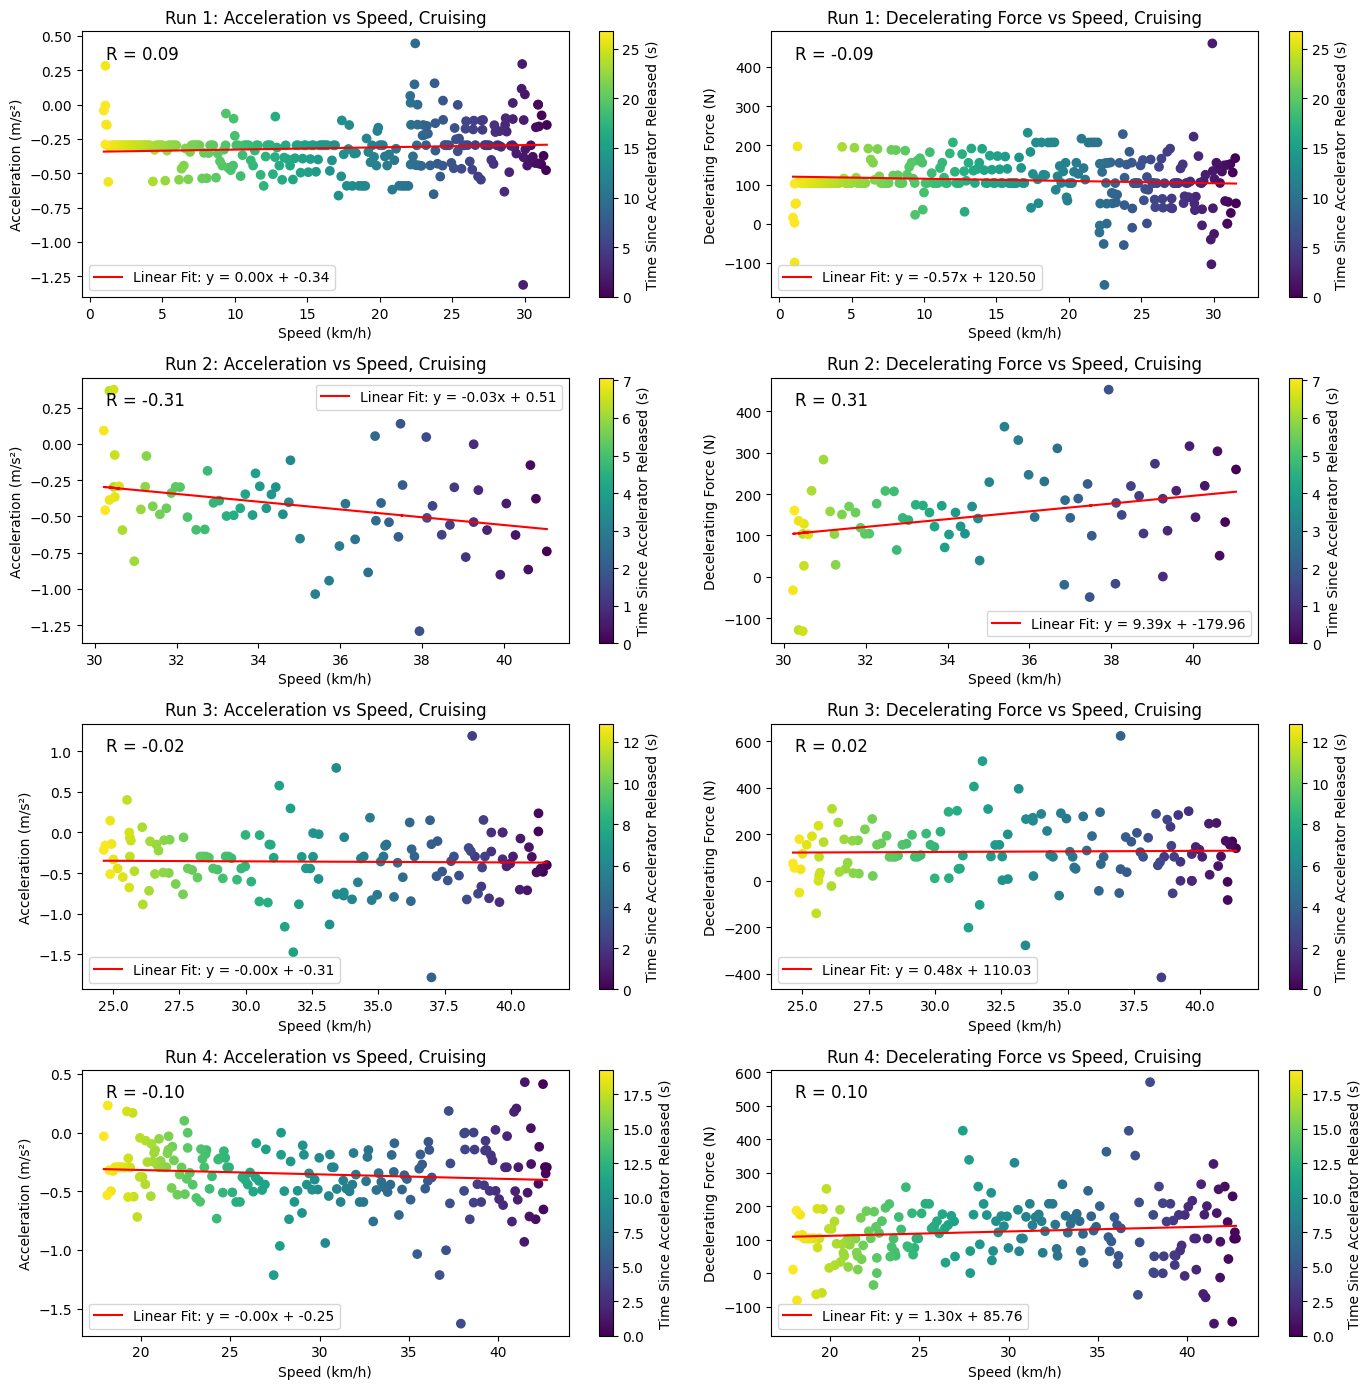

In [16]:
BRIGHTSIDE_MASS_KG = 350 # value taken from the 2025 analysis
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1 # F = ma, and flip sign to get slowing force
    speed_without_last = speed[:-1]
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:  
    
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line = slope * np.asarray(speed_without_last) + intercept

        
        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)

        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")

        ax.plot(speed_without_last, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
    

plt.tight_layout()
plt.show()


Ideally, the left column of plots should form a concave down parabola and the right column should form a concave up parabola. This is not the case; in fact, a linear fit seems to fit the data better.

Colors I'll reuse for plotting

In [19]:
COLORS = ["red", "orange", "green", "blue"]

Let's try plotting all 4 runs together and seeing if the trend we want is more visible this way.

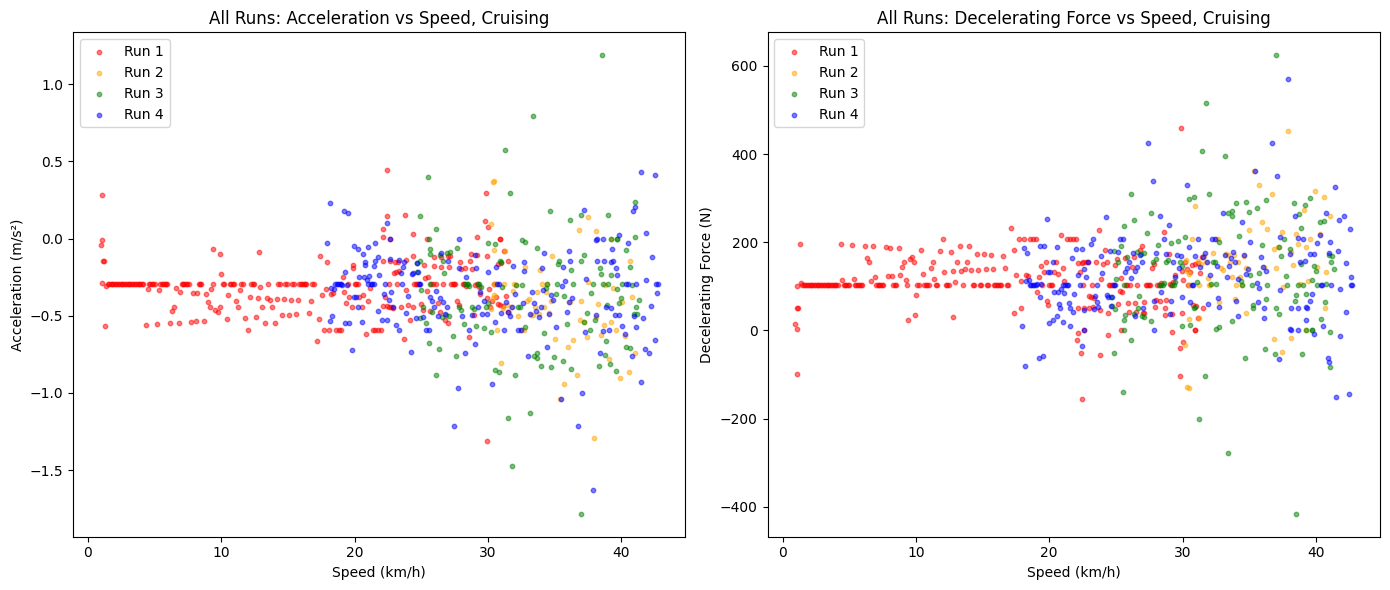

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_accel, ax_force = axes

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    acceleration: np.ndarray = (np.diff(speed_array) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]

    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_accel, acceleration, "Acceleration (m/s²)", "All Runs: Acceleration vs Speed, Cruising"),
        (ax_force, force, "Decelerating Force (N)", "All Runs: Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
        
plt.tight_layout()
plt.show()

The data is still pretty noisy. This is likely because:
- taking the derivative of the already noisy speed data amplifies the noise
- bumps in the road, incline of the road, slight steering adjustments during the test add noise


### Attempt 2: Deriving acceleration from speed data, then using the Savitsky-Golay filter

Let's try using the Savitsky-Golay filter to try and filter out some noise.

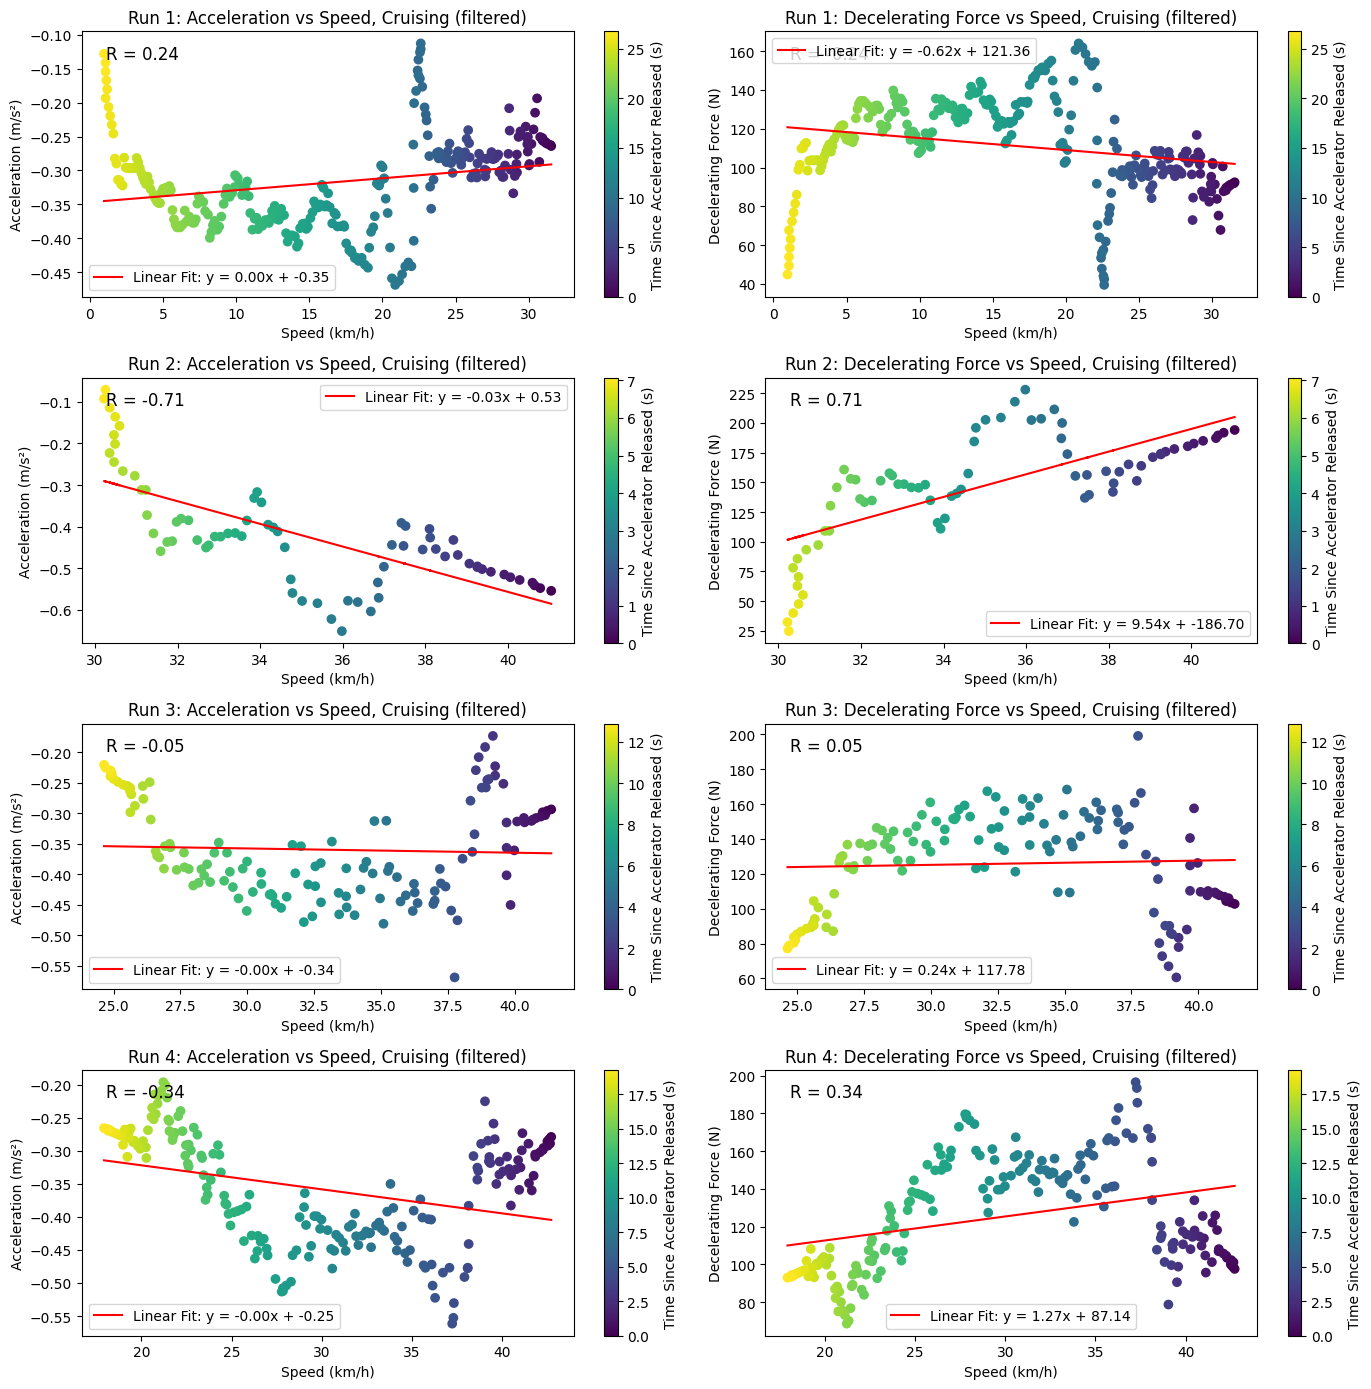

In [9]:
SAVGOL_WINDOW = 21    # number of points in each window, must be odd.
SAVGOL_POLY = 2       # polynomial order.

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    speed_smoothed = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]          
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising (filtered)"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising (filtered)"),
    ]:
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line = slope * speed_without_last + intercept

        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)
        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")
        ax.plot(speed_without_last, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
        

plt.tight_layout()
plt.show()

Note: I tested a few common WINDOW and POLY values but didn't do any rigorous tuning because a) All the manually tested results seemed similar and I'm not sure tuning these parameters will make a big difference and b) I'm not too familiar with these filters and would have to learn more about them (for example, if there are metrics to evaluate the "goodness" of a filter), which I feel like wouldn't be a good use of time because of point a.

Once again, let's try plotting all the runs together.

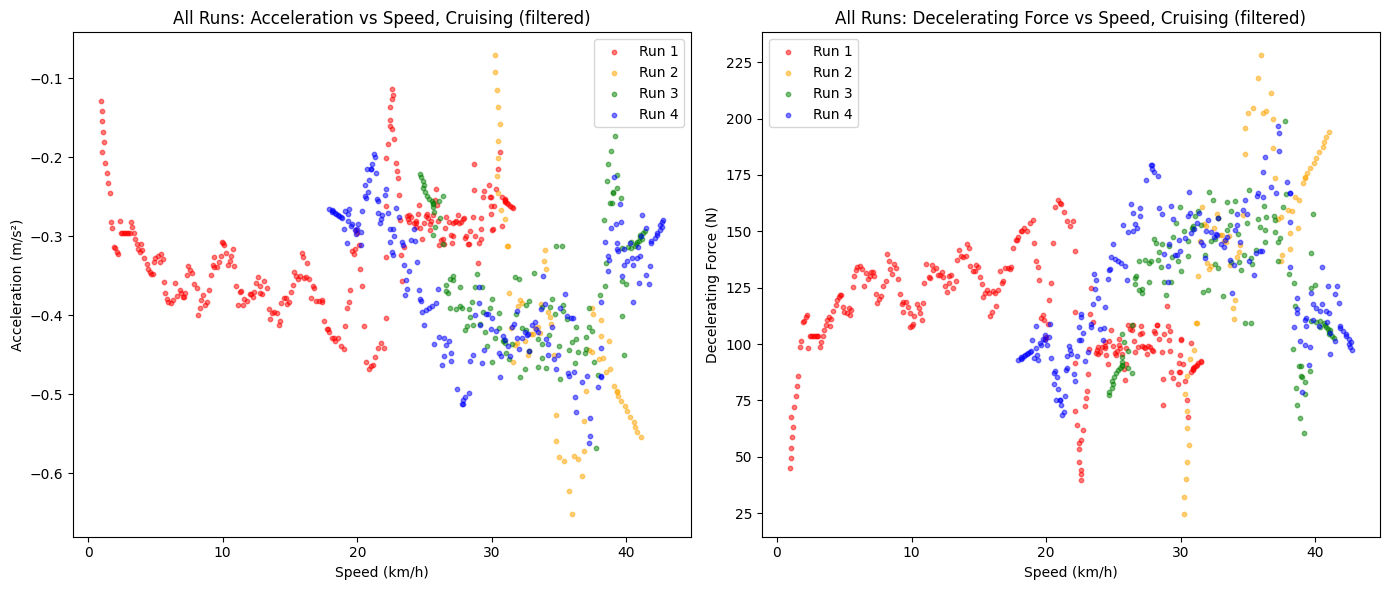

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_accel, ax_force = axes

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]

    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_accel, acceleration, "Acceleration (m/s²)", "All Runs: Acceleration vs Speed, Cruising (filtered)"),
        (ax_force, force, "Decelerating Force (N)", "All Runs: Decelerating Force vs Speed, Cruising (filtered)"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
        
plt.tight_layout()
plt.show()

Between roughly 21 km/h and 35 km/h, there is a visible trend in the direction we want. However, after discussion, it was decided that these results may not be reliable as the filter could just be creating a fake signal from messy data. We ended up calculating the drag area coefficient using attempt 3: IMU acceleration.

However, it could be worth calculating a CdA value with the curve fit on the filtered data? Perhaps first the cruise test window can be cropped a bit more to cut out the beginnings and ends where the major deviations from trends occur? If this topic is ever revisited, this could be the next step in the analysis

### Attempt 3: IMU Acceleration

A detailed explanation of the IMU acceleration data can be found [here](https://github.com/UBC-Solar/data_analysis/blob/main/v3/motor_analysis/imu_data_april_6.ipynb).  
Briefly, the z-direction is forwards, the unit for the IMU data is milligravities, and the zeroed_imu_z step in the cell below is to correct for the bias in the IMU reading.

In [22]:
# period of time where car is not moving
STATIC_START_TIME = datetime.fromisoformat("2026-04-02T20:04:00Z")
STATIC_STOP_TIME = datetime.fromisoformat("2026-04-02T20:07:00Z")
imu_z_static: TimeSeries = client.query_time_series(start=STATIC_START_TIME, stop=STATIC_STOP_TIME, field="Acceleration_Z")
z_static_accel = float(np.mean(imu_z_static)) # want to subtract this as a number below, not as a TimeSeries 

cruise_window_imu_zs: list[TimeSeries] = []
G = 9.81
for i, imu_z in enumerate(cruise_imu_zs):
    zeroed_imu_z = imu_z - z_static_accel
    cruise_window_imu_zs.append(zeroed_imu_z.slice(cruise_windows[i][0], cruise_windows[i][1]) / 1000 * G)

Plotting the acceleration and force graphs per-run 

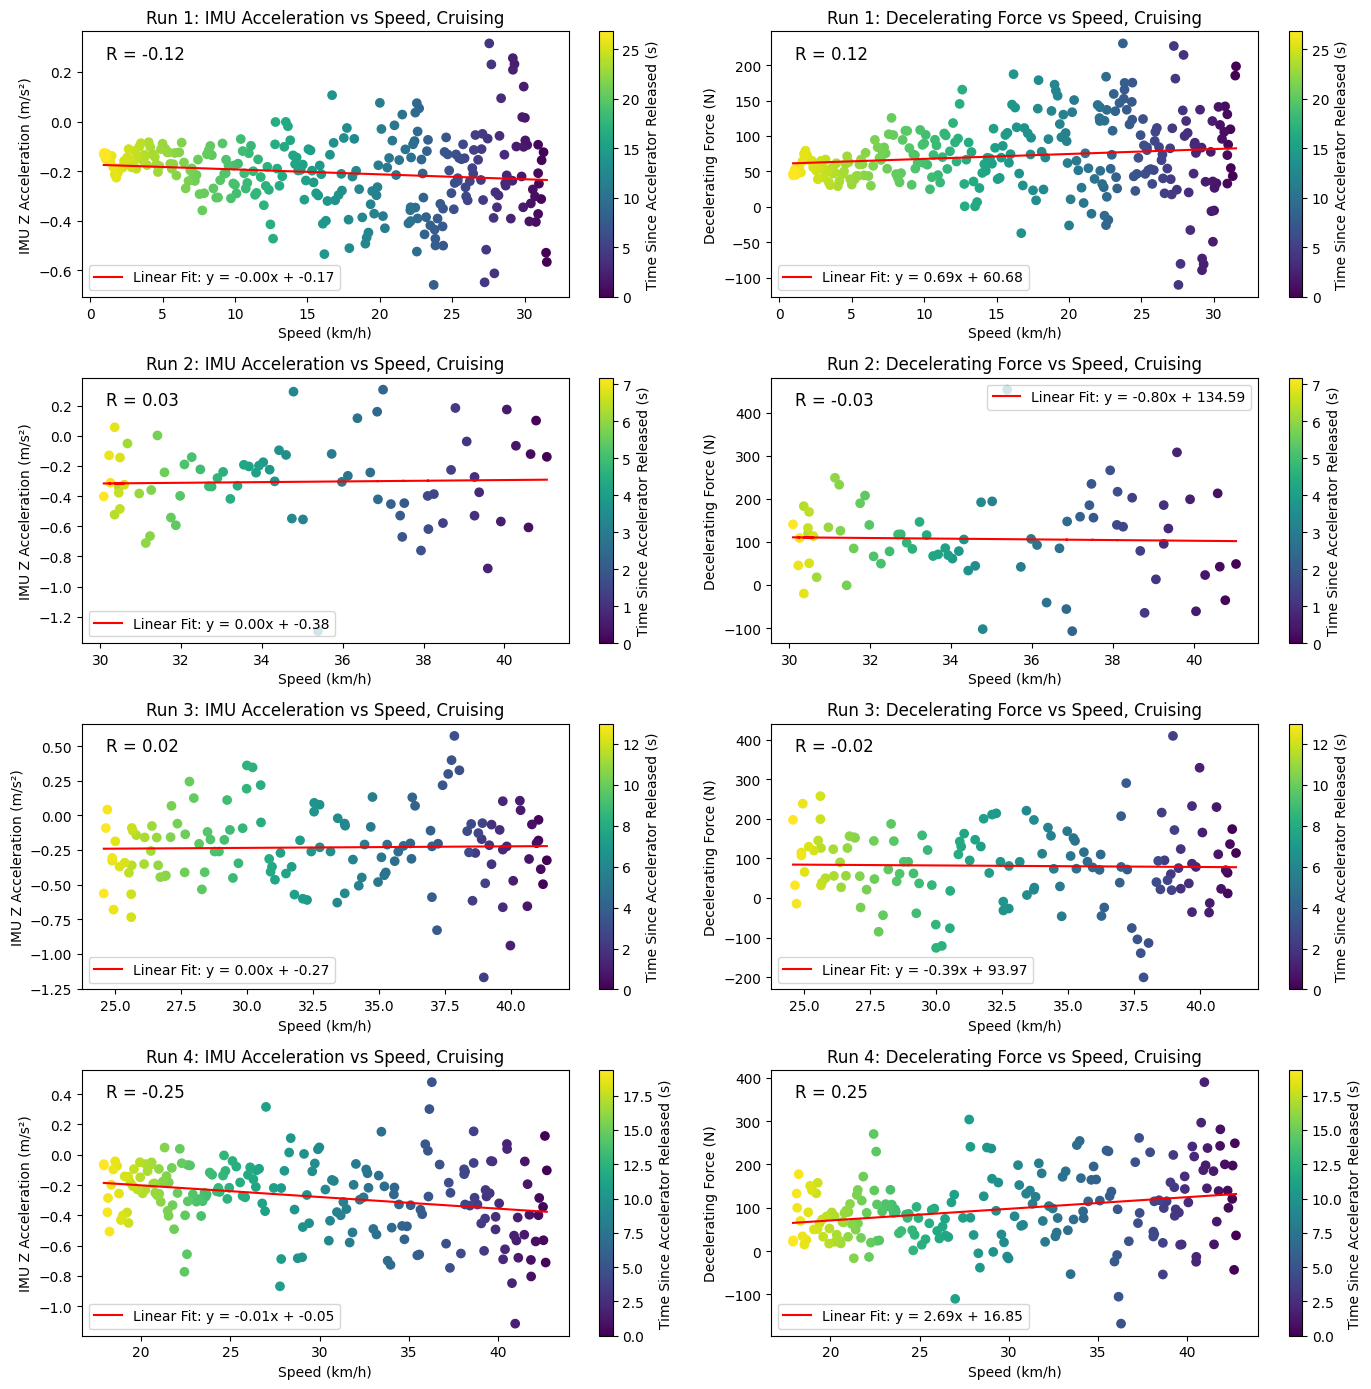

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    t_axis = speed.x_axis
    period = speed.period

    speed = np.asarray(speed)
    imu_z = np.asarray(imu_z)

    force = BRIGHTSIDE_MASS_KG * imu_z * -1
    time_since_cruising = t_axis - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, imu_z, "IMU Z Acceleration (m/s²)", f"Run {i+1}: IMU Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:
        slope, intercept, r_value, _, _ = stats.linregress(speed, y_data)
        fit_line = slope * speed + intercept

        scatter = ax.scatter(speed, y_data, c=time_since_cruising)
        ax.plot(speed, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()

plt.tight_layout()
plt.show()

And all the runs together

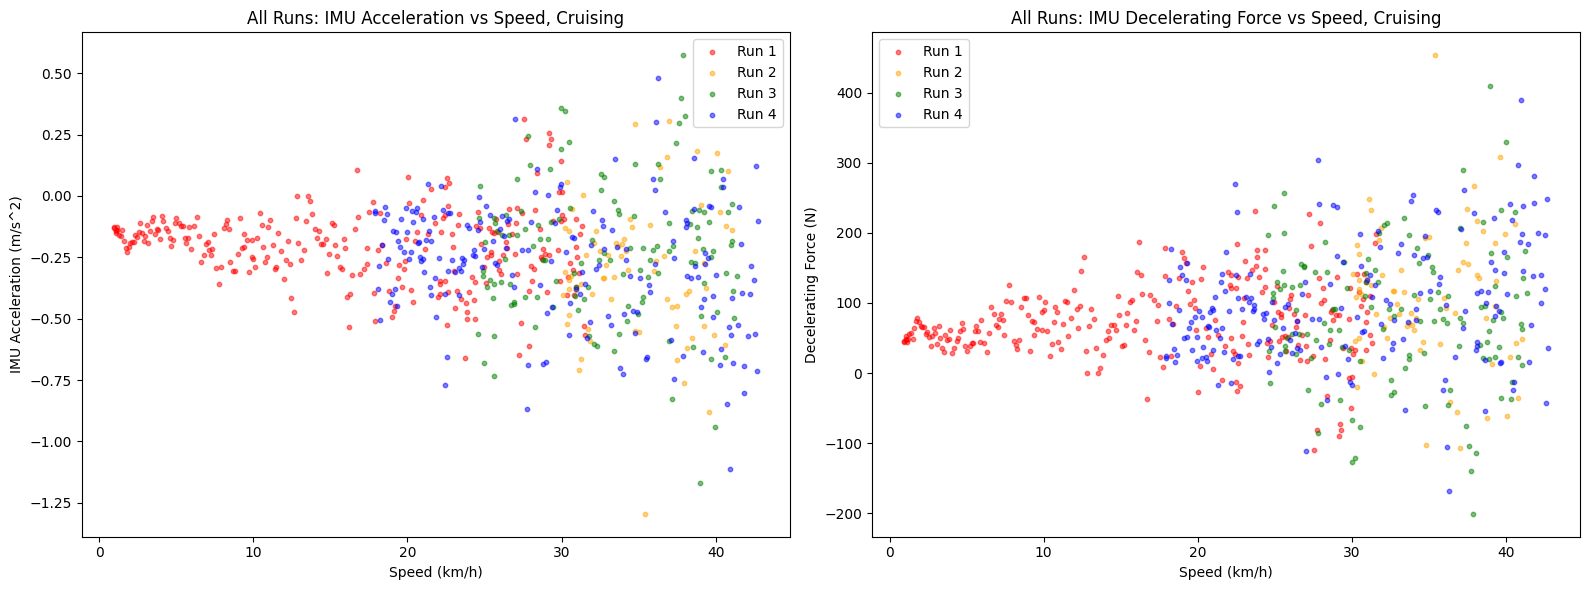

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_imu_accel, ax_imu_force = axes
 
for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    speed = np.asarray(speed)
    imu_z = np.asarray(imu_z)

    imu_force = BRIGHTSIDE_MASS_KG * imu_z * -1 
 
    for ax, y_data, y_label, title in [
        (ax_imu_accel, imu_z, "IMU Acceleration (m/s^2)",   "All Runs: IMU Acceleration vs Speed, Cruising"),
        (ax_imu_force, imu_force, "Decelerating Force (N)",     "All Runs: IMU Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed, y_data, c=COLORS[i], alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
 
plt.tight_layout()
plt.show()

There is a visible downwards trend on the left graph and upwards trend on the right graph. These graphs have the clearest data out of the three attempts, so we'll proceed with fitting a curve to the force graph with np.polyfit 

### np.polyfit

First, we compute the curve fit and its covariance matrix

In [14]:
all_speeds_imu = []
all_accels_imu = []

for speed, imu_z in zip(cruise_window_speeds, cruise_window_imu_zs):
    all_speeds_imu.append(np.asarray(speed)[:-1])
    all_accels_imu.append(np.asarray(imu_z)[:-1])

all_speeds_imu = np.concatenate(all_speeds_imu)
all_accels_imu = np.concatenate(all_accels_imu)

coeffs_accel, cov_accel = np.polyfit(all_speeds_imu, all_accels_imu, deg=2, cov=True)
coeffs_force = coeffs_accel * -BRIGHTSIDE_MASS_KG # force scales linearly with mass

cov_force = cov_accel * (BRIGHTSIDE_MASS_KG ** 2) # variance scales by the square of the mass
    
stdevs_accel = np.sqrt(np.diag(cov_accel))
stdevs_force = np.sqrt(np.diag(cov_force))

v_range = np.linspace(all_speeds_imu.min(), all_speeds_imu.max(), 300)

Next, we graph the curve fit on top of the acceleration and force graphs

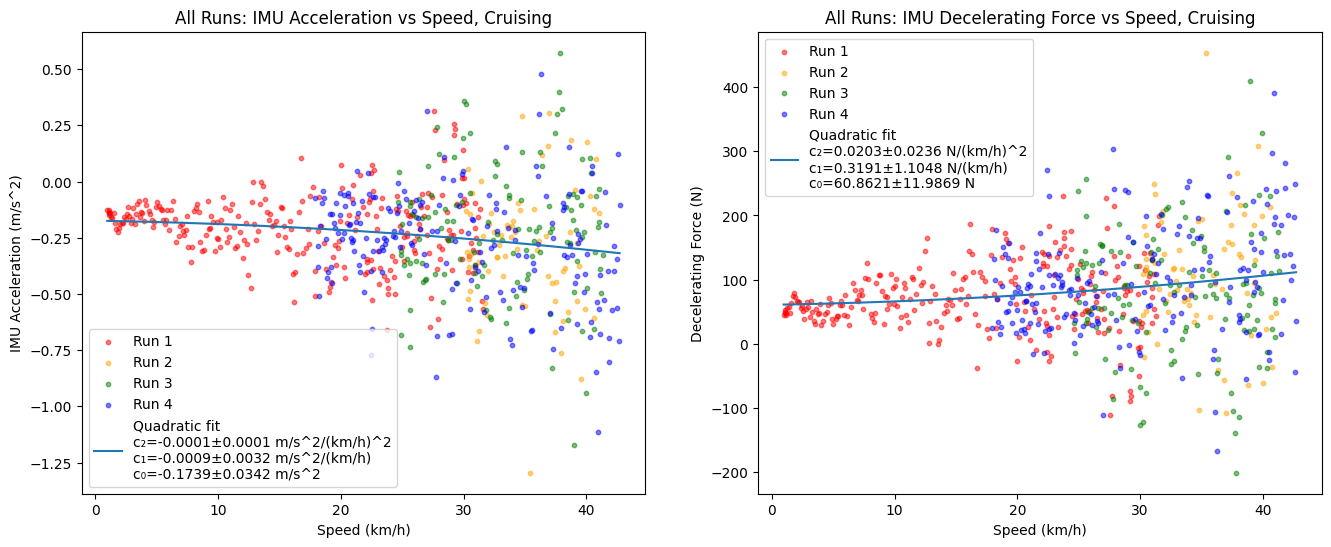

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_imu_accel, ax_imu_force = axes

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    speed_without_last = np.asarray(speed)[:-1]
    imu_z_without_last = np.asarray(imu_z)[:-1]
    imu_force = BRIGHTSIDE_MASS_KG * imu_z_without_last * -1
    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_imu_accel, imu_z_without_last, "IMU Acceleration (m/s^2)", "All Runs: IMU Acceleration vs Speed, Cruising"),
        (ax_imu_force, imu_force,          "Decelerating Force (N)",  "All Runs: IMU Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)

for ax, coeffs, stdevs, y_label in [
    (ax_imu_accel, coeffs_accel, stdevs_accel, "m/s^2"),
    (ax_imu_force, coeffs_force, stdevs_force, "N"),
]:
    c2, c1, c0 = coeffs
    stdev2, stdev1, stdev0 = stdevs
    fit_label = (f"Quadratic fit\n"
                 f"c₂={c2:.4f}±{stdev2:.4f} {y_label}/(km/h)^2\n"
                 f"c₁={c1:.4f}±{stdev1:.4f} {y_label}/(km/h)\n"
                 f"c₀={c0:.4f}±{stdev0:.4f} {y_label}")
    ax.plot(v_range, np.polyval(coeffs, v_range), label=fit_label)


ax_imu_accel.legend()
ax_imu_force.legend()
plt.show()

Here is the covariance matrix for the force curve

In [21]:
cov_force

array([[ 5.56820303e-04, -2.52363570e-02,  2.16300585e-01],
       [-2.52363570e-02,  1.22057224e+00, -1.17779268e+01],
       [ 2.16300585e-01, -1.17779268e+01,  1.43686248e+02]])

And here we convert the covariance matrix into a correlation matrix

In [22]:
cov_force / np.outer(stdevs_force, stdevs_force)

array([[ 1.        , -0.96802681,  0.76470259],
       [-0.96802681,  1.        , -0.88936392],
       [ 0.76470259, -0.88936392,  1.        ]])

### Results

Let's calculate the drag area coefficient from the coefficient c2 (0.0203 +/- 0.0236, from the graph above). I'll use units to guide this process.
- The units are N / (km/h)^2; let's get the denominator to (m/s)^2. To do so, we multiply by 12.96
- Now we have N / (m/s)^2. These units simplify to kg/m.
- To get from this coefficient to the drag area coefficient, the formula is to mulitply by 2 and divide by air density (we'll use 1.225 kg/m^3). This means our units are now (kg/m) / (kg/m^3)
- Simplifying our units, we get m^2, which is a unit of area!

In [23]:
0.0203 * 12.96 * 2 / 1.225

0.4295314285714285

We do the same for the uncertainty 

In [24]:
0.0236 * 12.96 * 2 / 1.225

0.49935673469387754

Our drag area coefficient, calculated from the coast-down tests,  is 0.42953 +/- 0.49936

Clearly, the data is too noisy for an accurate estimate to be made. The uncertainty range is bigger than the number itself. It is at least worth noting that a [previosuly calculated drag area coefficient](https://docs.google.com/spreadsheets/d/1qZOvJP8j49muN_7OXM4JxYIiAH3Xi5s9Vi7ATgiVYDo/edit?pli=1&gid=380865959#gid=380865959) (0.13821) falls in this range.

### Unused analyses

#### all plots together

I tried plotting all 12 graphs together on one plot (3 attempts of getting acceleration * 4 runs), but the result was just a very messy plot

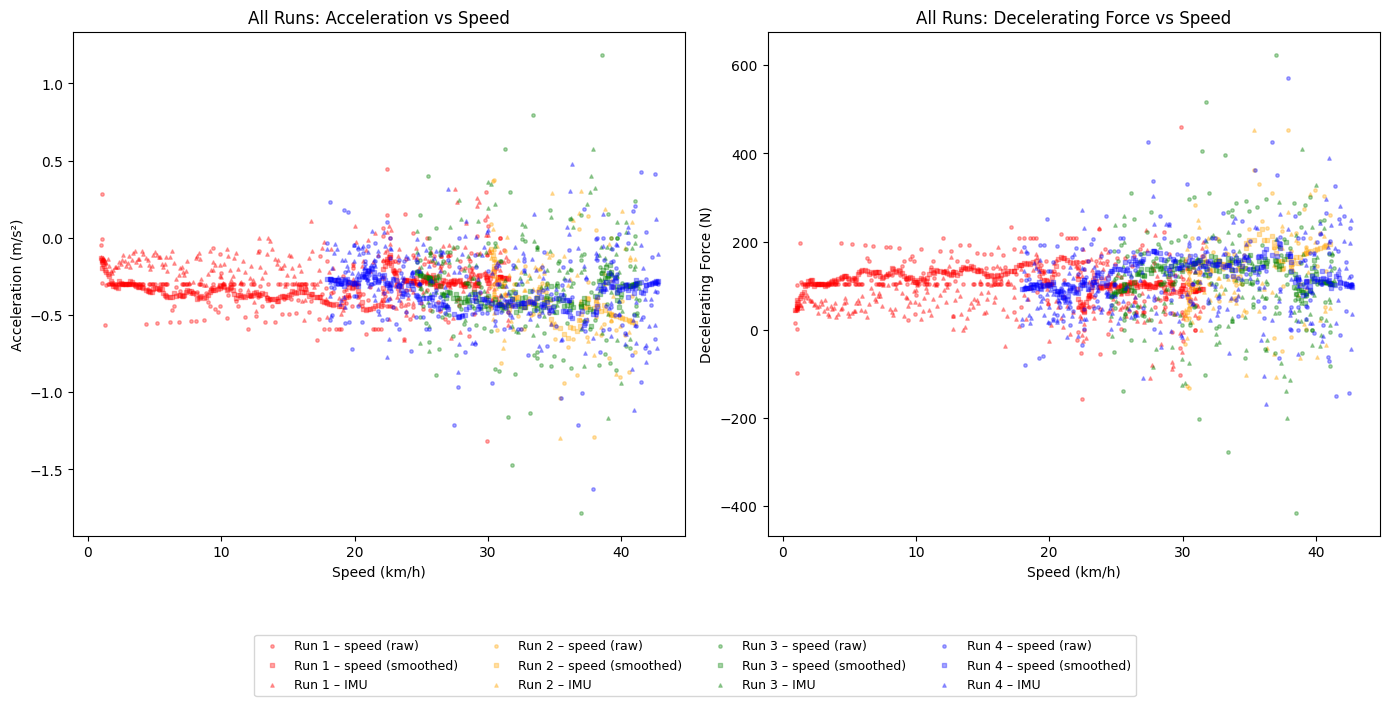

In [18]:
PROPERTIES = [
    # (label_suffix,  marker, alpha, size)
    ("speed (raw)",      "o", 0.33, 6),
    ("speed (smoothed)", "s", 0.33, 6),
    ("IMU",              "^", 0.33, 6),
]

fig, (ax_accel, ax_force) = plt.subplots(1, 2, figsize=(14, 6))

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    period   = speed.period
    color    = COLORS[i]

    speed_array = np.asarray(speed)
    speed_smoothed = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)
    speed_without_last = speed_array[:-1]

    raw_accel: np.ndarray = (np.diff(speed_array)    / period) / KMH_PER_MPS
    smooth_accel: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    imu_accel_array = np.asarray(imu_z[:-1])

    y_accels = [raw_accel, smooth_accel, imu_accel_array]
    y_forces  = [BRIGHTSIDE_MASS_KG * a * -1 for a in y_accels]

    for (suffix, marker, alpha, size), y_accel, y_force in zip(PROPERTIES, y_accels, y_forces):
        label = f"Run {i+1} – {suffix}"
        ax_accel.scatter(speed_without_last, y_accel,
                         c=color, marker=marker, alpha=alpha, s=size, label=label)
        ax_force.scatter(speed_without_last, y_force,
                         c=color, marker=marker, alpha=alpha, s=size, label=label)

for ax, title, ylabel in [
    (ax_accel, "All Runs: Acceleration vs Speed",       "Acceleration (m/s²)"),
    (ax_force, "All Runs: Decelerating Force vs Speed", "Decelerating Force (N)"),
]:
    ax.set_title(title)
    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel(ylabel)

# Legend outside to avoid covering data
handles, labels = ax_accel.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=4, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.18))

plt.tight_layout()
plt.show()

#### acceleration vs time graphs

these graphs were originally presented with the acceleration/force vs time graphs, but they don't really provide information neccessary for determining the CdA

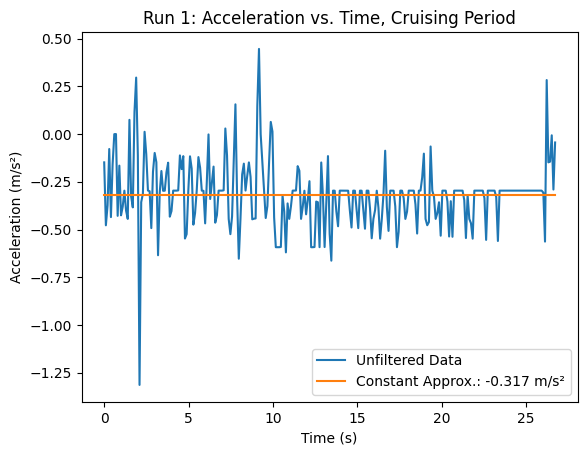

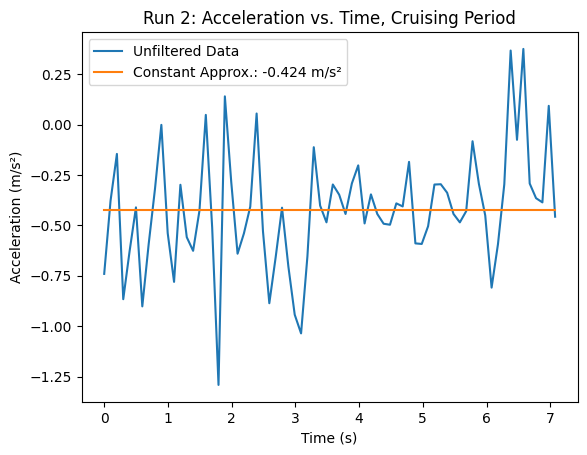

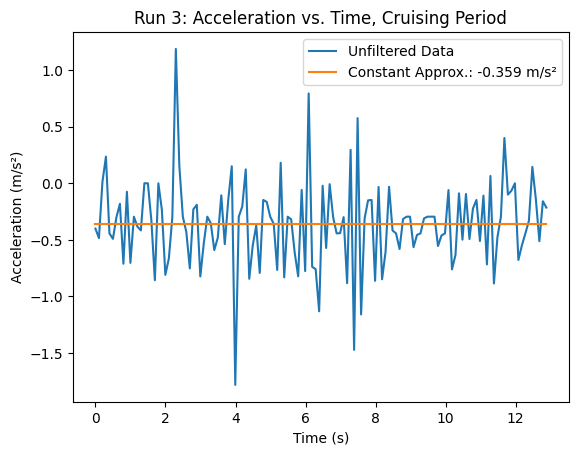

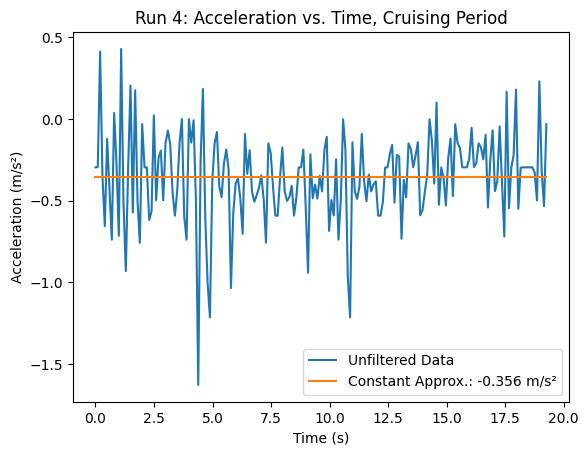

In [19]:
for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    mean_accel = np.mean(acceleration)
    constant_approx = np.ones(len(acceleration)) * mean_accel

    plt.plot(t_axis[:-1], acceleration, label="Unfiltered Data")
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show() 

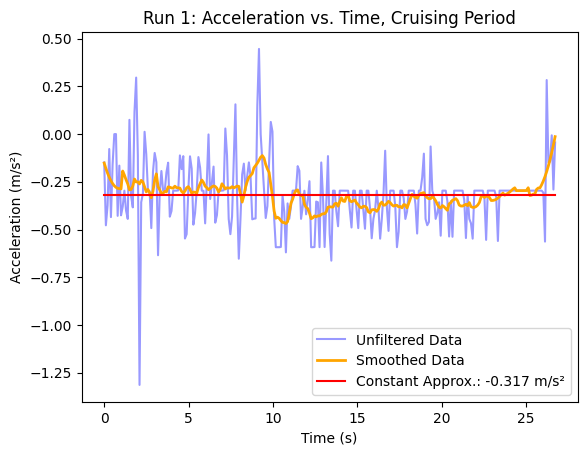

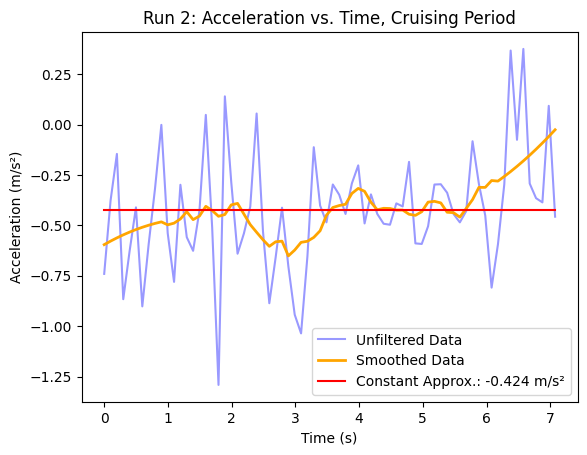

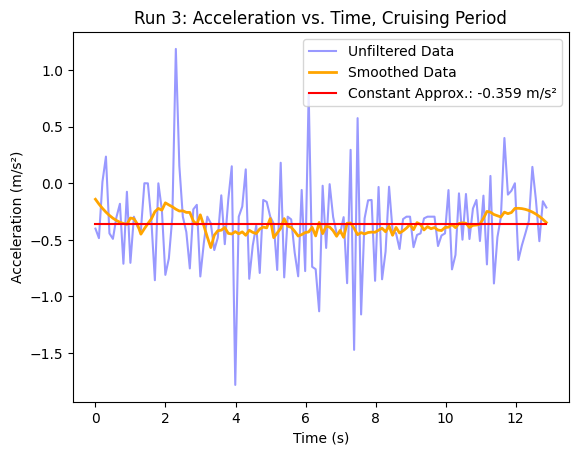

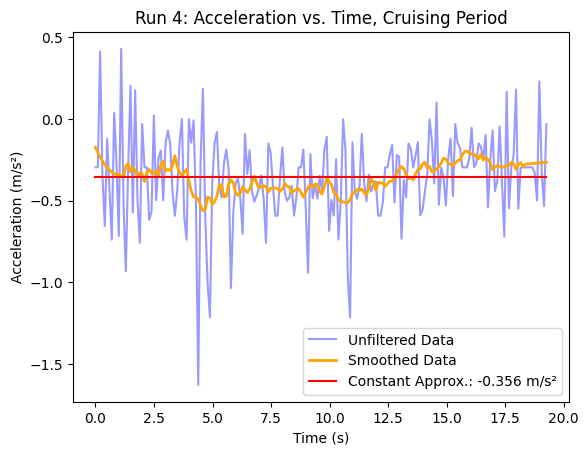

In [20]:
from scipy.signal import savgol_filter

SAVGOL_WINDOW = 21    # number of points in each window, must be odd — tune this
SAVGOL_POLY = 3       # polynomial order — 3 is standard

for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    speed_array = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration_raw: np.ndarray = (np.diff(speed_array) / period) / KMH_PER_MPS
    acceleration_smooth: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS

    mean_accel = np.mean(acceleration_raw)
    constant_approx = np.ones(len(acceleration_raw)) * mean_accel

    plt.plot(t_axis[:-1], acceleration_raw, label="Unfiltered Data", alpha=0.4, color="blue")
    plt.plot(t_axis[:-1], acceleration_smooth, label="Smoothed Data", color="orange", linewidth=2)
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²", color="red")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show()